In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Utility Functions

def from_numpy(*args, **kwargs):
    return torch.from_numpy(*args, **kwargs).float().to(device)


def get_numpy(tensor):
    return tensor.to("cpu").detach().numpy()


# Plotting
def visualize_mb_data(dataset):
    mb_dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values)
    z = calculator.U_split(x, y).cpu()

    fig, ax = plt.subplots()
    colorbar = ax.imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
    ax.set(xlabel="x-axis", ylabel="y-axis", title="Muller Brown Training Data")
    plt.colorbar(colorbar)

    # also plot batch from dataloader
    for i, batch in enumerate(mb_dataloader):
        ax.scatter(batch[:, 1], batch[:, 0], color='red', s=0.1)
        
    ax.set_xlim([calculator.Lx, calculator.Hx])
    ax.set_ylim([calculator.Ly, calculator.Hy])

    plt.show()
    plt.close()


def plot_losses(
    train_losses: np.ndarray, test_losses: np.ndarray, title: str
) -> None:
    plt.figure()
    n_epochs = len(test_losses) - 1
    x_train = np.linspace(0, n_epochs, len(train_losses))
    x_test = np.arange(n_epochs + 1)

    plt.plot(x_train, train_losses, label="train loss")
    plt.plot(x_test, test_losses, label="test loss")
    plt.legend()
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("NLL")

def save_multi_scatter_2d(data: np.ndarray) -> None:
    fig, axs = plt.subplots(3, 3, figsize=(10, 10))
    num_points = 100
    x_values = torch.linspace(calculator.Lx, calculator.Hx , num_points)
    y_values = torch.linspace(calculator.Ly, calculator.Hy, num_points)

    x, y = torch.meshgrid(x_values, y_values)
    z = calculator.U_split(x, y).cpu()
    for i in range(3):
        for j in range(3):
        
            colorbar = axs[i, j].imshow(z, extent=(x_values.min(), x_values.max(), y_values.min(), y_values.max()), vmin=calculator.U_min, vmax=calculator.U_max, origin='lower', cmap='viridis', aspect='auto')
            plt.colorbar(colorbar)
            axs[i, j].scatter(data[i * 3 + j, :, 0], data[i * 3 + j, :, 1])
    plt.title("Muller Brown Samples")


def plot_results(train_losses, test_losses, samples):

    print(f"Final Test Loss: {test_losses[-1]:.4f}")

    plot_losses(
        train_losses,
        test_losses,
        f"Loss Plot",
    )

    save_multi_scatter_2d(samples)

In [3]:
from mb_dataset import MBDataset
from mb_calculator import MullerBrownPotential

calculator = MullerBrownPotential(device = "cpu")

train_dataset = MBDataset(preload_sim_dir="data/temp=800_timestep=20.0_friction=0.01", train = True)
test_dataset = MBDataset(preload_sim_dir="data/temp=800_timestep=20.0_friction=0.01", train = False)

Loading simulations from directory: data/temp=800_timestep=20.0_friction=0.01


100%|██████████| 100/100 [00:32<00:00,  3.04it/s]


Loading simulations from directory: data/temp=800_timestep=20.0_friction=0.01


100%|██████████| 100/100 [00:25<00:00,  4.00it/s]


In [8]:
def linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps, total_steps, lr_min=0.0, lr_max=1.0):
    """
    Linear warmup with cosine decay 
    """
    def lr_lambda(current_step: int):
        if current_step < warmup_steps:
            # Linear warmup
            warmup_factor = current_step / float(max(1, warmup_steps))
            return lr_min + warmup_factor * (lr_max - lr_min)
        else:
            # Cosine decay
            progress = (current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return lr_min + 0.5 * (lr_max - lr_min) * (1 + torch.cos(torch.tensor(torch.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class DiffusionMLP(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, device):
        super(DiffusionMLP, self).__init__()
        self.device = device
        self.in_dim = in_dim
        self.PI = torch.tensor([np.pi]).to(device)

        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc3 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc4 = nn.Linear(hidden_dim, hidden_dim) 
        self.fc5 = nn.Linear(hidden_dim, out_dim)  

    def forward(self, x):
        x = F.relu(self.fc1(x))  
        x = F.relu(self.fc2(x))  
        x = F.relu(self.fc3(x))  
        x = F.relu(self.fc4(x))  
        x = self.fc5(x)          
        return x

    def ddpm_update(self, x, eps_hat, t, tm1):
        sigma_t = torch.sin(self.PI / 2 * t)
        sigma_tm1 = torch.sin(self.PI / 2 * tm1)
        alpha_t = torch.cos(self.PI / 2 * t)
        alpha_tm1 = torch.cos(self.PI / 2 * tm1)
        zeta_t = sigma_tm1 / sigma_t * torch.sqrt(1 - (alpha_t **2) / (alpha_tm1 **2))
        x_tm1 = alpha_tm1 * (x - sigma_t * eps_hat) / alpha_t + \
                eps_hat * torch.sqrt(torch.clip(sigma_tm1**2 - zeta_t**2, 0)) + \
                zeta_t * torch.randn_like(x).to(self.device)

        return x_tm1
        

    def sample(self, num_samples, num_steps):
        with torch.no_grad():
            ts = torch.linspace(1 - 1e-4, 1e-4, num_steps + 1).unsqueeze(-1).to(self.device)
            x = torch.randn((num_samples, self.in_dim - 1)).to(self.device)
            # import pdb; pdb.set_trace()
            #begin reverse diffusion process
       
            for i in range(num_steps):
                t = ts[i].repeat(x.shape[0]).unsqueeze(-1)
                tm1 = ts[i + 1].repeat(x.shape[0]).unsqueeze(-1)
                eps_hat = self.forward(torch.cat([x, t], dim = 1))
                x = self.ddpm_update(x, eps_hat, t, tm1)
            return x
        

def train_mb_diffusion(train_dataset, test_dataset, model):
    """

    Returns
    - a (# of training iterations,) numpy array of train losses evaluated every minibatch
    - a (# of num_epochs + 1,) numpy array of test losses evaluated at the start of training and the end of every epoch
    - a numpy array of size (9, 2000, 2) of samples drawn from your model.
      Draw 2000 samples for each of 9 different number of diffusion sampling steps
      of evenly logarithmically spaced integers 1 to 512
      hint: np.power(2, np.linspace(0, 9, 9)).astype(int)
    """

    """ YOUR CODE HERE """
    # Train 100 epochs, batch size 1024, Adam with LR 1e-3 (100 warmup steps, cosine decay to 0)
    device = torch.device(torch.cuda.current_device())
    n_epochs = 50
    batch_size = 1024
    PI = torch.tensor([np.pi]).to(device)
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    scheduler = linear_warmup_cosine_decay_lr_scheduler(optimizer, warmup_steps = 100, \
                                                        total_steps = n_epochs * int(len(train_dataset) / batch_size), \
                                                        lr_min=0.0, lr_max=1.0)

    #normalize training data
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False)
    
    mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
    std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
    # train_data = (train_data - train_mean) / train_std
    # test_data = (test_data - train_mean) / train_std

    train_losses = []
    test_losses = []
    for _ in tqdm(range(n_epochs)):
        model.train()
        for x in train_dataloader:
            optimizer.zero_grad()
            x = x.to(device)
            x = (x - mean) / std
            #sample diffusion timestep
            t = torch.rand((x.shape[0], 1)).to(device)
            #compute noise strength
            alpha = torch.cos(PI / 2 * t)
            sigma = torch.sin(PI / 2 * t)
            #add random noise
            noise = torch.randn_like(x)
            noised_x = alpha * x + sigma * noise
            #concatenate t for conditioning
            noised_x = torch.cat([noised_x, t], dim = 1).to(torch.float32)
            #forward pass
            pred_noise = model(noised_x).to(torch.float32)
            #compute loss and optimize
            loss = F.mse_loss(pred_noise, noise)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_losses.append(loss.unsqueeze(-1))

        model.eval()
        tls = []
        with torch.no_grad():
            for x in test_dataloader:
                #sample diffusion timestep
                x = x.to(device)
                x = (x - mean) / std
                t = torch.rand((x.shape[0], 1)).to(device)
                #compute noise strength
                alpha = torch.cos(PI / 2 * t)
                sigma = torch.sin(PI / 2 * t)
                #add random noise
                noise = torch.randn_like(x)
                noised_x = alpha * x + sigma * noise
                #concatenate t for conditioning
                noised_x = torch.cat([noised_x, t], dim = 1).to(torch.float32)
                #forward pass
                pred_noise = model(noised_x).to(torch.float32)
                #compute loss and optimize
                loss = F.mse_loss(pred_noise, noise)
                tls.append(loss.unsqueeze(-1))
            test_loss = torch.cat(tls).sum(0) / len(tls)
            test_losses.append(test_loss.unsqueeze(-1))
            # print("Test loss: ", test_losses[-1].item())
            
    all_samples = torch.stack([model.sample(2000, step) for step in np.power(2, np.linspace(0, 9, 9)).astype(int)])
    all_samples = all_samples*std + mean
    return get_numpy(torch.cat(train_losses)), get_numpy(torch.cat(test_losses)), get_numpy(all_samples)


/home/sanjeevr/miniforge3/envs/om-diffusion/lib/python3.12/site-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


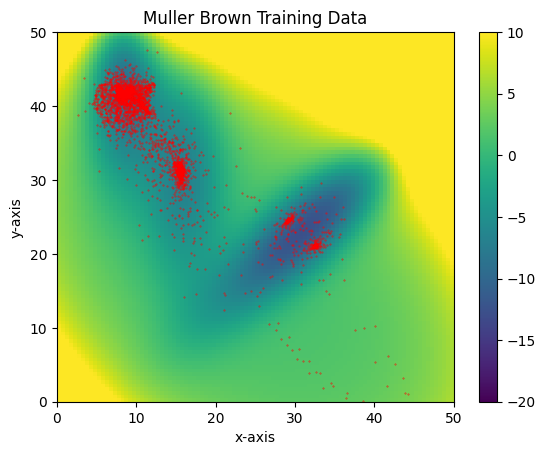

In [5]:
visualize_mb_data(train_dataset)

In [9]:
device = torch.device(torch.cuda.current_device())
model = DiffusionMLP(3, 64, 2, device).to(device).to(torch.float32)
train_losses, test_losses, all_samples = train_mb_diffusion(train_dataset, test_dataset)

/tmp/ipykernel_2128099/2547167446.py:94: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(train_dataset.mean).to(device).to(torch.float32)
/tmp/ipykernel_2128099/2547167446.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(train_dataset.std).to(device).to(torch.float32)
100%|██████████| 50/50 [00:19<00:00,  2.60it/s]


In [11]:
all_samples = torch.stack([model.sample(2000, step) for step in np.power(2, np.linspace(0, 9, 9)).astype(int)])

plot_results(train_losses, test_losses, all_samples)

NameError: name 'model' is not defined